# Supplementary Fig. 23 — TETRIS-seq rearrangement caller on positive-control dilutions

Detection of known AML-associated chromosomal rearrangements across serial dilutions, using the TETRIS-seq
rearrangement caller. Four rearrangements (one per panel), each tested across four serial dilutions (three for
KMT2A::MLLT3): **actual VAF** (x) vs **inferred VAF** (y), log–log, dotted line = perfect concordance
(inferred = actual). The plotted inferred VAF is the max of the two reciprocal fusion calls; for t(8;21)
RUNX1::RUNX1T1 (two distinct events) it is the sum of the two events. Non-detected events are plotted at the
`0` gridline. Each panel is annotated with its two-sided Pearson r, p-value and mean absolute error (MAE, in
VAF %).

## How these values were produced
The plotted VAFs are the output of the **TETRIS-seq chromosomal-rearrangement caller**, whose code is in
`Supplementary_Fig_22.ipynb` (`run_translocation_pipeline`, which infers breakpoints from discordant and
soft-clipped reads and calculates the VAF at each breakpoint). Here it was run on a dilution series: DNA from
four AML samples with a known rearrangement, each diluted into normal DNA to the actual VAFs shown on the
x-axis, sequenced with the custom TETRIS-seq CNV panel. Sample labels are `<sample>_<dilution>`
(e.g. `24642_25` = sample 24642 at the 25% dilution).

## Data availability
Self-contained: the caller's inferred VAFs for the dilution series are held as literal values in this
notebook (they are also in Supplementary Table S4). The rearrangement-positive samples are from an
independent AML sample set, not from UKCTOCS, and their sequencing data are not part of this repository, so
no individual-level data are needed to reproduce the figure.

## 1. Imports and colours

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import pearsonr

In [2]:
# colorbrewer greys used for axes / gridlines / dilution guide-lines
grey2 = '#cccccc'
grey3 = '#969696'

## 2. Positive-control VAF data

In [3]:
# --- Positive-control inferred VAFs (highest of the two reciprocal breakpoint calls) ---
# AML samples with a known rearrangement, diluted into normal DNA (values as decimal fractions);
# produced by the rearrangement caller in Supplementary_Fig_22.ipynb (see note above).
inferred_VAFs = {
    'KMT2A::MLLT3': {'24642_1': 0.0033971587399629, '24642_5': 0.021095689, '24642_25': 0.151504799},
    'DEK::NUP214':  {'24792_1': 0.003129954, '24792_5': 0.015014747, '24792_25': 0.073988115, '24792_50': 0.162190551},
    'RUNX1::RUNX1T1':{'39321_1': 0, '39321_5': 0.0132, '39321_25': 0.0888, '39321_50': 0.1770},
    'MYH11::CBFB':  {'39326_1': 0, '39326_5': 0.100874532, '39326_25': 0.229530331, '39326_50': 0.388630646},
}

# Actual (expected) VAF for each diluted sample (decimal fraction).
expected_VAFs = {
    '24642_1': 0.005,  '24642_5': 0.025,  '24642_25': 0.125,
    '24792_1': 0.005,  '24792_5': 0.025,  '24792_25': 0.125,  '24792_50': 0.25,
    '39321_1': 0.005,  '39321_5': 0.025,  '39321_25': 0.125,  '39321_50': 0.25,
    '39326_1': 0.0048, '39326_5': 0.02,   '39326_25': 0.12,   '39326_50': 0.24,
}

# Per-panel actual/inferred VAFs in VAF-% units, EXCLUDING non-detected events, used for the Pearson r / MAE
# statistics shown on each panel (for t(8;21) the inferred VAF is the sum of the two events).
panel_stats_data = {
    'KMT2A::MLLT3':  ([12.50, 2.50, 0.50],       [15.15, 2.10, 0.34]),
    'DEK::NUP214':   ([25.00, 12.50, 2.50, 0.50],[16.20, 7.40, 1.50, 0.31]),
    'RUNX1::RUNX1T1':([25.00, 12.50, 2.50],      [17.70, 8.88, 1.32]),
    'MYH11::CBFB':   ([24.20, 12.10, 2.40],      [38.86, 22.95, 10.09]),
}


## 3. The figure (4 rearrangements x serial dilutions)

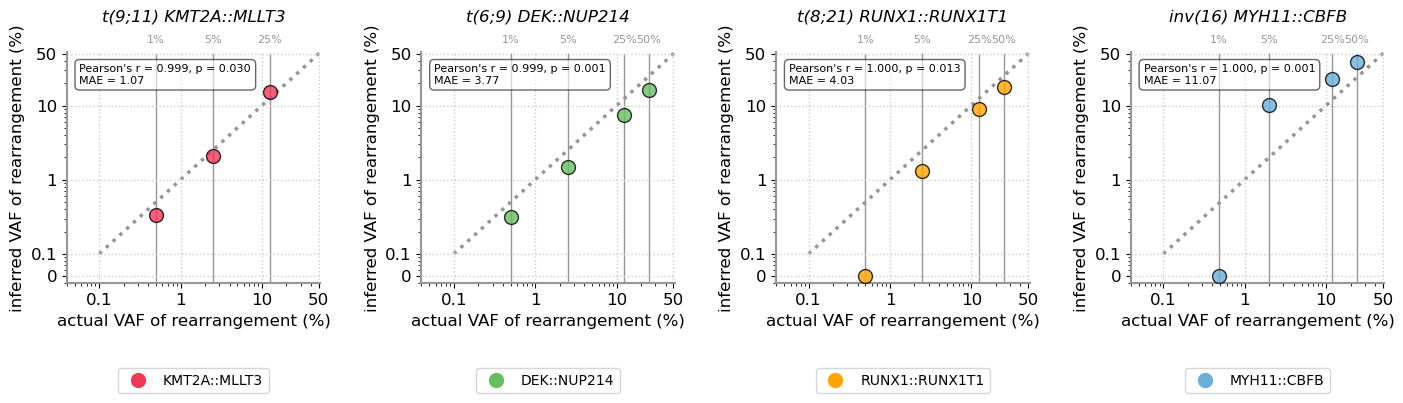

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(17, 3))
plt.rcParams['ps.fonttype'] = 42
plt.subplots_adjust(wspace=0.4)
ax1, ax2, ax3, ax4 = axes

# published panel order: t(9;11), t(6;9), t(8;21), inv(16)
axis   = {'KMT2A::MLLT3': ax1, 'DEK::NUP214': ax2, 'RUNX1::RUNX1T1': ax3, 'MYH11::CBFB': ax4}
titles = {'KMT2A::MLLT3': 't(9;11) KMT2A::MLLT3', 'DEK::NUP214': 't(6;9) DEK::NUP214',
          'RUNX1::RUNX1T1': 't(8;21) RUNX1::RUNX1T1', 'MYH11::CBFB': 'inv(16) MYH11::CBFB'}
colors = {'KMT2A::MLLT3': '#ef3857', 'DEK::NUP214': '#67be61',
          'RUNX1::RUNX1T1': 'orange', 'MYH11::CBFB': '#6baed6'}

for fusion, samples in inferred_VAFs.items():
    ax = axis[fusion]
    for sample, vaf in samples.items():
        exp = expected_VAFs[sample]
        obs = 0.0005 if vaf == 0 else vaf          # non-detected -> plot on the '0' gridline
        ax.scatter(exp, obs, color=colors[fusion], edgecolor='k', s=100, alpha=0.8, zorder=50)
        ax.plot([exp, exp], [0.00007, 0.5], color=grey3, lw=1, zorder=0)   # dilution guide line
        dilution = sample.split('_')[-1] + '%'                             # sample suffix = dilution factor
        ax.text(exp, 0.66, dilution, ha='center', va='bottom',
                fontsize=8, color=grey3, clip_on=False)                     # dilution label

for fusion, ax in axis.items():
    exp, obs = panel_stats_data[fusion]
    r, p = pearsonr(exp, obs)
    mae = np.mean(np.abs(np.array(exp) - np.array(obs)))
    ax.set_title(titles[fusion], fontsize=12, style='italic', pad=22)
    ax.text(0.05, 0.95, f"Pearson's r = {r:.3f}, p = {p:.3f}\nMAE = {mae:.2f}",
            transform=ax.transAxes, fontsize=8, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.6, pad=0.4))
    ax.legend([Line2D([0], [0], marker='o', color=colors[fusion], lw=0, markersize=10)],
              [fusion], loc='center', bbox_to_anchor=(0.5, -0.42), ncol=1, fontsize=10, fancybox=True)

for ax in axes.flatten():
    ax.plot([0.001, 0.52], [0.001, 0.52], color=grey3, lw=2.5, linestyle=':', zorder=0)
    ax.set_xlabel('actual VAF of rearrangement (%)', fontsize=12)
    ax.set_ylabel('inferred VAF of rearrangement (%)', fontsize=12)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(0.0004, 0.52); ax.set_ylim(0.0004, 0.52)
    ax.set_yticks([0.0005, 0.001, 0.01, 0.1, 0.5])
    ax.set_yticklabels(['0', '0.1', '1', '10', '50'], fontsize=12)
    ax.set_xticks([0.001, 0.01, 0.1, 0.5])
    ax.set_xticklabels(['0.1', '1', '10', '50'], fontsize=12)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    for s in ['bottom', 'left']:
        ax.spines[s].set_linewidth(1.5); ax.spines[s].set_color(grey3)
    ax.grid(color=grey2, linewidth=1, linestyle=':', zorder=0)

plt.show()


## 4. Correlation statistics (caption numbers)

In [5]:
# --- Overall correlation across all detected events (pooled), for the caption ---
pooled_exp, pooled_obs = [], []
for exp, obs in panel_stats_data.values():
    pooled_exp += exp; pooled_obs += obs
r, p = pearsonr(pooled_exp, pooled_obs)
mae = np.mean(np.abs(np.array(pooled_exp) - np.array(pooled_obs)))
print(f"Overall (pooled): Pearson r = {r:.2f}, p = {p:.3f}, MAE = {mae:.2f}%")
for fusion, (exp, obs) in panel_stats_data.items():
    r, p = pearsonr(exp, obs)
    mae = np.mean(np.abs(np.array(exp) - np.array(obs)))
    print(f"  {fusion:16s}: r = {r:.3f}, p = {p:.3f}, MAE = {mae:.2f}%  (n = {len(exp)})")


Overall (pooled): Pearson r = 0.79, p = 0.001, MAE = 4.89%
  KMT2A::MLLT3    : r = 0.999, p = 0.030, MAE = 1.07%  (n = 3)
  DEK::NUP214     : r = 0.999, p = 0.001, MAE = 3.77%  (n = 4)
  RUNX1::RUNX1T1  : r = 1.000, p = 0.013, MAE = 4.03%  (n = 3)
  MYH11::CBFB     : r = 1.000, p = 0.001, MAE = 11.07%  (n = 3)
